Copyright Hewlett Packard Enterprise Development LP.

Rewriting the Arkouda v2 version of Data_Across_All_Caps in pandas for a fair comparison

In [1]:
import pandas as pd
import numpy as np
import time

In [2]:
dir = "/lus/scratch/khandeka/dev/arkouda-telemetry-analysis/parquet-traces-for-LSMS-application/"

power_cap200 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_200_16_events.parquet"
power_cap300 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_300_16_events.parquet"
power_cap400 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_400_16_events.parquet"
power_cap500 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_500_16_events.parquet"
power_cap600 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_600_16_events.parquet"
power_cap700 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_700_16_events.parquet"
power_cap800 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_800_16_events.parquet"
power_cap900 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_900_16_events.parquet"
power_cap1000 = "paper_lsms_scorep_papi_wombat_grace_hopper_plugins_production_1000_16_events.parquet"

# List of power cap files
power_caps = [power_cap200, power_cap300, power_cap400, power_cap500, power_cap600, power_cap700, power_cap800, power_cap900, power_cap1000]
# power_caps = [power_cap1000]

power_cap_names = [name.split('_')[-3] for name in power_caps[::-1]]
print(power_cap_names)  # Output: ['800', '900', '1000']

['1000', '900', '800', '700', '600', '500', '400', '300', '200']


In [3]:
def preprocess_power_data(df):
    df = df[df["values"] != "nan"]
    df['values'] = df['values'].str.strip('[]').astype(float) / 1000
    return df

def find_leave_events(df):
    leave_events = df[df['event'] == 'Leave']
    # leave_events = leave_events.sort_values("time") # They are already sorted by time
    return leave_events

In [4]:
def process_power_data_approximation(df_events, df_power):
    gpudf_time = df_events["time"].values
    powerdf_time = df_power["time"].values
    powerdf_power = df_power["values"].values

    if powerdf_time[0] > 0:
        powerdf_time = np.insert(powerdf_time, 0, 0)
        powerdf_power = np.insert(powerdf_power, 0, powerdf_power[0])

    indices = np.searchsorted(powerdf_time, gpudf_time, side='right') - 1
    aligned_power = powerdf_power[indices]

    if np.isnan(aligned_power).any():
        raise ValueError("NaN values found in the aligned power data.")
    if aligned_power.size != gpudf_time.size:
        raise ValueError("Aligned power data size does not match event data size.")

    return aligned_power

In [5]:
def get_inclusive_energy(df_events):
    setup_time = time.time()
    df_power = df_events[df_events["metric"] == "MetricInstance [21]: 'metric_class': MetricClass [20], 'recorder': Location [47244640256] '', 'metric_scope': MetricScope.SYSTEM_TREE_NODE, 'scope': SystemTreeNode [1] 'wombat35'"].copy()

    regions = df_events[df_events["region"].notna()]
    regions = df_events[df_events["region"] != "nan"]  # Filter out rows where region is NaN

    df_gpuevents = regions[regions["location"] == "CUDA[0:7]"].copy()
    setup_time = time.time() - setup_time

    duration_time = 0
    energy_mask_time = 0
    energy_df_slices_time = 0
    trapz_vectorized_time = 0
    misc_time = 0
    inner_loop_time = 0

    start_time = time.time()
    df_power = preprocess_power_data(df_power)
    approximated_power = process_power_data_approximation(df_events, df_power)

    unique_regions = df_gpuevents['region'].unique()
    region_times = []
    region_energies = []
    preprocess_time = time.time() - start_time
    print(f"Number of regions: {len(unique_regions)}")

    for region in unique_regions:
        inner_loop_start = time.time()
        dur_start = time.time()

        df_r = df_gpuevents[df_gpuevents['region'] == region]
        if df_r.empty:
            print(f"Region: {region}, has no data points, skipping")
            continue

        enter_events = df_r[df_r['event'] == 'Enter']
        leave_events = find_leave_events(df_r)

        enter_times = enter_events['time'].values
        leave_times = leave_events['time'].values

        leave_indices = np.searchsorted(leave_times, enter_times, side="right")
        valid_indices = leave_indices < len(leave_times)

        valid_enter_times = enter_times[valid_indices]
        valid_leave_times = leave_times[valid_indices]
        durations = valid_leave_times - valid_enter_times
        total_region_time = durations.sum()
        region_times.append(total_region_time)
        duration_time += time.time() - dur_start

        # Vectorized energy calculation
        energy_mask_start = time.time()
        enter_idx = np.searchsorted(df_events['time'], valid_enter_times, side='left')
        leave_idx = np.searchsorted(df_events['time'], valid_leave_times, side='right')

        delta = np.zeros(len(df_events) + 1, dtype=int)
        delta[enter_idx] += 1
        delta[leave_idx] -= 1

        energy_mask = np.cumsum(delta[:-1]) > 0
        energy_mask_time += time.time() - energy_mask_start

        slice_time = time.time()
        energy_values = np.where(energy_mask, approximated_power, 0)
        energy_df_slices_time += time.time() - slice_time
        trapz_start = time.time()
        total_region_energy = np.trapz(energy_values, df_events['time'])
        trapz_vectorized_time += time.time() - trapz_start
        misc_start = time.time()
        region_energies.append(total_region_energy)
        misc_time += time.time() - misc_start
        inner_loop_time += time.time() - inner_loop_start

    df_energies = pd.DataFrame({
        'region': unique_regions,
        'energy': region_energies,
        'duration': region_times
    }).sort_values('energy', ascending=False)
    df_energies = df_energies[df_energies['energy'] > 1.0]
    end_time = time.time()
    runtime = end_time - start_time
    print(f"Setup Time: {setup_time:.2f} seconds")
    print(f"Runtime: {runtime:.2f} seconds")
    print(f"Preprocess Time: {preprocess_time:.2f} seconds")
    print(f"Inner Loop Time: {inner_loop_time:.2f} seconds")
    print(f"  Durations Time: {duration_time:.2f} seconds")
    print(f"  Energy Mask Time: {energy_mask_time:.2f} seconds")
    print(f"  Energy DF Slices Time: {energy_df_slices_time:.2f} seconds")
    print(f"  Trapz Vectorized Time: {trapz_vectorized_time:.2f} seconds")
    print(f"  Misc Time: {misc_time:.2f} seconds")


    for _, row in df_energies.iterrows():
        print(f"Region: {row['region']}, Total Energy: {row['energy']:.2f} J, Total Time: {row['duration']:.2f} s")

    return df_energies.head(8)


In [6]:
def get_avg_power(df_energies):
    return {region: avg_power for region, avg_power in zip(df_energies['region'].values, df_energies['energy'].values/df_energies['duration'].values)}


In [7]:
def get_speedup_perf_drop(df_energies, baseline):
    speedup_energy = {}
    performance_drop = {}
    energy_saved = {}

    for _, row in df_energies.iterrows():
        region = row['region']
        energy = row['energy']
        runtime = row['duration']
        baseline_runtime = baseline.loc[baseline['region'] == region, 'duration'].values[0]
        baseline_energy = baseline.loc[baseline['region'] == region, 'energy'].values[0]

        if baseline_runtime and baseline_energy and runtime and energy:
            speedup = (baseline_runtime * baseline_energy) / (runtime * energy)
            energy_saved[region] = 100 * (energy - baseline_energy) / baseline_energy if energy != 0 else None
            performance_drop[region] = 100 * (runtime - baseline_runtime) / baseline_runtime if runtime != 0 else None
        else:
            speedup = None
            energy_saved[region] = None
            performance_drop[region] = None

        speedup_energy[region] = speedup

    return energy_saved, performance_drop, speedup_energy


In [8]:
avg_power_data = {}
energy_saved_data = {}
performance_drop_data = {}
speedup_energy_data = {}

read_time = 0
initial_calc_time = 0
energy_calc_time = 0
other_calc_time = 0

for cap in power_caps[::-1]:
    read_start_time = time.time()
    df_events = pd.read_parquet(dir+cap, columns=['time', 'metric', 'values', 'region','location','event'])
    read_time += time.time() - read_start_time

    init_calc_start_time = time.time()
    df_events["time"] = pd.to_numeric(df_events["time"])  # Convert time to seconds
    df_events["time"] = (df_events['time'] - df_events['time'].iloc[0]) / 1000000000
    initial_calc_time += time.time() - init_calc_start_time

    energy_calc_start_time = time.time()
    df_energies = get_inclusive_energy(df_events)
    energy_calc_time += time.time() - energy_calc_start_time

    other_calc_start_time = time.time()

    if cap == power_cap1000:
        baseline = df_energies

    # use arrays and dataframes
    avg_power = get_avg_power(df_energies)
    energy_saved, performance_drop, speedup_energy  = get_speedup_perf_drop(df_energies, baseline)

    # Store metrics for each region across power caps
    for region in df_energies['region'].values:
        if region not in avg_power_data:
            avg_power_data[region] = []
            energy_saved_data[region] = []
            performance_drop_data[region] = []
            speedup_energy_data[region] = []

        avg_power_data[region].append(avg_power.get(region, None))
        energy_saved_data[region].append(energy_saved.get(region, None))
        performance_drop_data[region].append(performance_drop.get(region, None))
        speedup_energy_data[region].append(speedup_energy.get(region, None))
    other_calc_time += time.time() - other_calc_start_time

print(f"Read Time: {read_time:.2f} seconds")
print(f"Initial Calculation Time: {initial_calc_time:.2f} seconds")
print(f"Energy Calculation Time: {energy_calc_time:.2f} seconds")
print(f"Other Calculation Time: {other_calc_time:.2f} seconds")

Number of regions: 36
Setup Time: 9.26 seconds
Runtime: 22.61 seconds
Preprocess Time: 0.74 seconds
Inner Loop Time: 21.85 seconds
  Durations Time: 5.29 seconds
  Energy Mask Time: 7.29 seconds
  Energy DF Slices Time: 2.24 seconds
  Trapz Vectorized Time: 7.02 seconds
  Misc Time: 0.00 seconds
Region: sm90_xmma_gemm_cf64cf64_f64f64_cf64_nn_n_tilesize64x64x32_stage3_warpsize4x2x1_tensor16x8x16_execute_kernel__5x_cublas, Total Energy: 42876.67 J, Total Time: 77.79 s
Region: buildKKRMatrixMultiplyKernelCuda, Total Energy: 20537.42 J, Total Time: 34.91 s
Region: COMPUTE IDLE, Total Energy: 16928.03 J, Total Time: 8.89 s
Region: sm90_xmma_gemm_cf64cf64_f64f64_cf64_nn_n_tilesize32x32x32_stage3_warpsize2x2x1_tensor16x8x16_execute_kernel__5x_cublas, Total Energy: 4670.28 J, Total Time: 8.03 s
Region: getrf_pivot<getrf_params_<double2, 512, 2, 512, 64, 16> >, Total Energy: 2289.38 J, Total Time: 4.07 s
Region: getrf_pivot<getrf_params_<double2, 512, 2, 512, 32, 32> >, Total Energy: 2278.95 J,

```
Setup Time: 9.26 seconds
Runtime: 22.61 seconds
Preprocess Time: 0.74 seconds
Inner Loop Time: 21.85 seconds
  Durations Time: 5.29 seconds
  Energy Mask Time: 7.29 seconds
  Energy DF Slices Time: 2.24 seconds
  Trapz Vectorized Time: 7.02 seconds
  Misc Time: 0.00 seconds
```

```
Read Time: 150.23 seconds
Initial Calculation Time: 172.11 seconds
Energy Calculation Time: 281.95 seconds
Other Calculation Time: 0.03 seconds
```


On my mac,

```
Setup Time: 6.86 seconds
Runtime: 13.06 seconds
Preprocess Time: 0.74 seconds
Inner Loop Time: 12.32 seconds
  Durations Time: 3.59 seconds
  Energy Mask Time: 4.41 seconds
  Energy DF Slices Time: 1.41 seconds
  Trapz Vectorized Time: 2.91 seconds
  Misc Time: 0.00 seconds
```

```
Read Time: 89.49 seconds
Initial Calculation Time: 111.30 seconds
Energy Calculation Time: 183.43 seconds
Other Calculation Time: 0.02 seconds
```


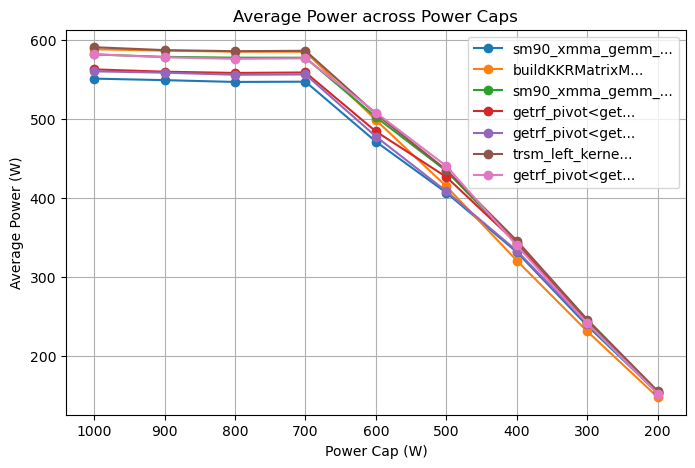

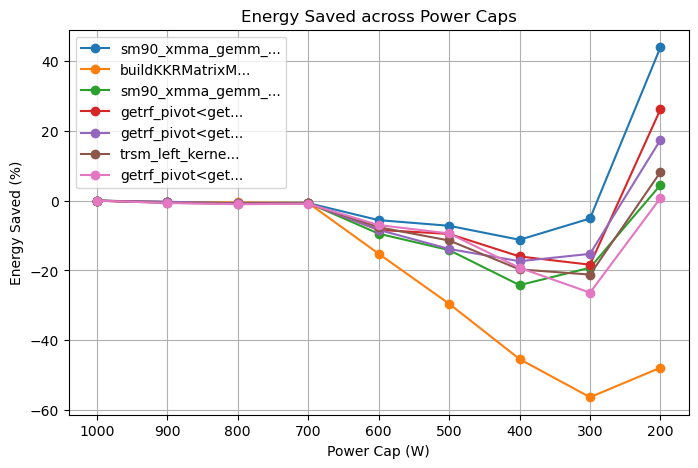

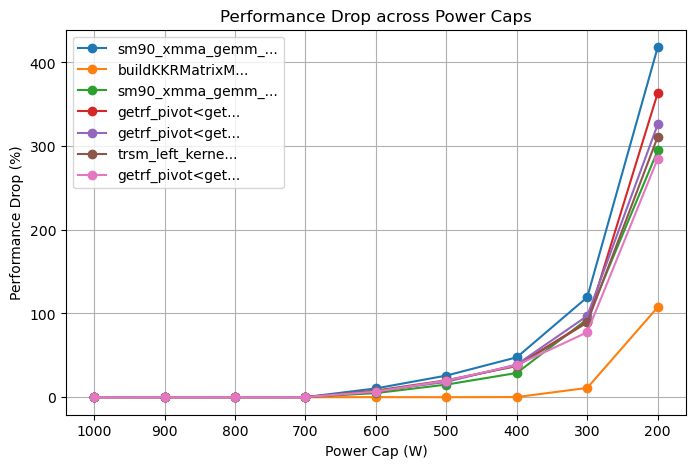

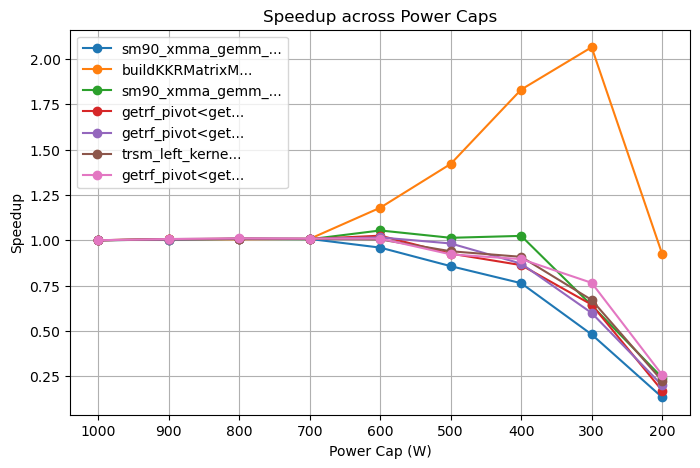

In [9]:
import matplotlib.pyplot as plt

# Plotting function
def plot_metric_across_power_caps(data, title, ylabel):
    plt.figure(figsize=(8, 5))
    for region, values in data.items():
        if region == "COMPUTE IDLE":
            continue
        # Shorten the region name for the legend
        short_region = region[:15] + "..." if len(region) > 15 else region
        plt.plot(power_cap_names, values, marker='o', label=short_region)
    plt.xlabel("Power Cap (W)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

# Plot each metric
plot_metric_across_power_caps(avg_power_data, "Average Power across Power Caps", "Average Power (W)")
plot_metric_across_power_caps(energy_saved_data, "Energy Saved across Power Caps", "Energy Saved (%)")
plot_metric_across_power_caps(performance_drop_data, "Performance Drop across Power Caps", "Performance Drop (%)")
plot_metric_across_power_caps(speedup_energy_data, "Speedup across Power Caps", "Speedup")